In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Root Finding

# Bisection Method

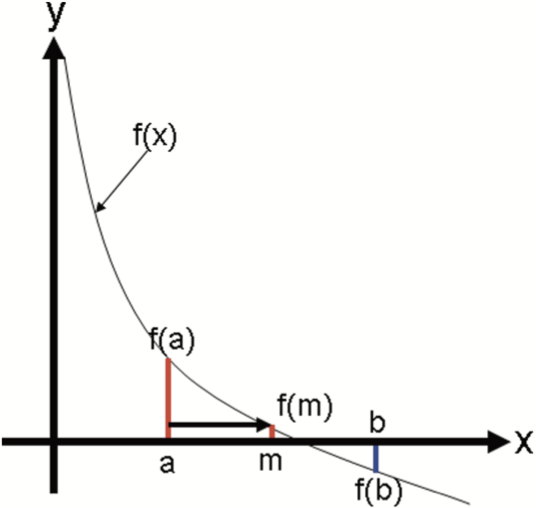

## Algorithm
1. Start with an interval: Choose $[a, b]$ such that $f(a) \cdot f(b) < 0$.

1. Find the midpoint: Calculate $c = \frac{a+b}{2}$. 

1. Evaluate $f(c)$:If $f(c) = 0$ (or is within a very small tolerance), $c$ is the root. 

    * If $f(a) \cdot f(c) < 0$, the root lies in the left sub-interval $[a, c]$. Set $b = c$. 

    * If $f(c) \cdot f(b) < 0$, the root lies in the right sub-interval $[c, b]$. Set $a = c$.

1. Repeat: Iterate until the interval width $|b - a|$ is smaller than a predefined tolerance $\epsilon$.

## Convergence

The Bisection Method is linearly convergent. At each step, the error is exactly halved. Error after $n$ iterations:$$e_n = \frac{|b - a|}{2^n}$$

# Newton Raphson Method

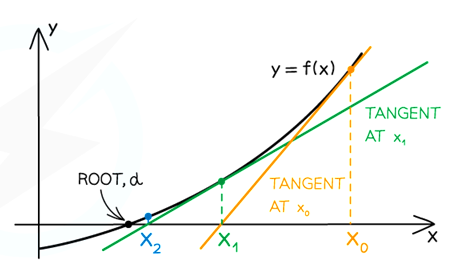

## Algorithm

$$f'(x_i) = \frac{f(x_{i+1}) - f(x_i)}{x_{i+1} - x_i}$$

$$x_{i+1} - x_i = \frac{f(x_{i+1}) - f(x_i)}{f'(x_i)}$$

$$x_{i+1} = x_i + \frac{f(x_{i+1}) - f(x_i)}{f'(x_i)}$$

Put $f(x_{i+1}) = \text{root} = 0$

$$x_{i+1} = x_i - \frac{f(x_i)}{f'(x_i)}$$

## Derivation of Error Reduction with iterations (Convergence)

Let $x_T = \text{true solution}$ 

At iteration $i$, let $\epsilon_i$ be the error: 

$ \epsilon_i = x_i - x_T$

At iteration $i+1$,

$\epsilon_{i+1} = x_{i+1} - x_T $

We know that 
$x_{i+1} = x_i - \frac{f(x_i)}{f'(x_i)} $

$ \epsilon_{i+1} = x_i - \frac{f(x_i)}{f'(x_i)} - x_T$ 

$\epsilon_{i+1} =\epsilon_i - \frac{f(x_i)}{f'(x_i)}$

$x_i = x_T + \epsilon_i$

$f(x_T + \epsilon_i) = f(x_T) + \epsilon_i f'(x_T) + \frac{1}{2} \epsilon_i^2 f''(x_T) $

$ = \epsilon_i f'(x_T) + \frac{1}{2} \epsilon_i^2 f''(x_T)      \because f(x_T) = 0 $

$f'(x_T + \epsilon_i) = f'(x_T) + \epsilon_i f''(x_T)$

$$\epsilon_{i+1} = \epsilon_i - \frac{\epsilon_i f'(x_T) + \frac{1}{2} \epsilon_i^2 f''(x_T)}{f'(x_T) + \epsilon_i f''(x_T)}$$

$$\epsilon_{i+1} = \frac{\frac{1}{2} \epsilon_i^2 f''(x_T)}{f'(x_T) + \epsilon_i f''(x_T)}$$ 

$= O(\epsilon_i^2)$ i.e. if $\epsilon_i \approx 0.01 \Rightarrow \epsilon_{i+1} \approx 10^{-4}$

i.e. near the root, the solution approaches the root very fast (parabolic)

Bisection method works well away from the root

Newton Raphson suffers from infinity error if derivative $f'(x_i)$ goes to 0

In [11]:
def bisection(f, a, b, tol=1e-6, max_iter=100):
    iters = 0
    while (b - a) / 2.0 > tol and iters < max_iter:
        c = (a + b) / 2.0
        if f(c) == 0: 
            break
        elif f(a) * f(c) < 0: 
            b = c
        else: 
            a = c
        iters += 1
    return (a + b) / 2.0, iters

In [12]:
def newton_raphson(f, df, x0, tol=1e-6 , max_iter=100):
    iters = 0
    while abs(f(x0)) > tol and iters < max_iter:
        x0 = x0 - f(x0) / df(x0)
        iters += 1
    return x0, iters

In [31]:
# Define the function and its derivative
f = lambda x: x**2 - 5
df = lambda x: 2*x

# Run
bisect_root, bisect_iters = bisection(f, 2, 10000)
newton_root, newton_iters = newton_raphson(f, df, 10000)

# Print results
print(f"Analytical:     Root =", np.sqrt(5))
print(f"Bisection:      Root = {bisect_root:.6f} (took {bisect_iters} iterations)")
print(f"Newton-Raphson: Root = {newton_root:.6f} (took {newton_iters} iterations)")

Analytical:     Root = 2.23606797749979
Bisection:      Root = 2.236068 (took 33 iterations)
Newton-Raphson: Root = 2.236068 (took 16 iterations)


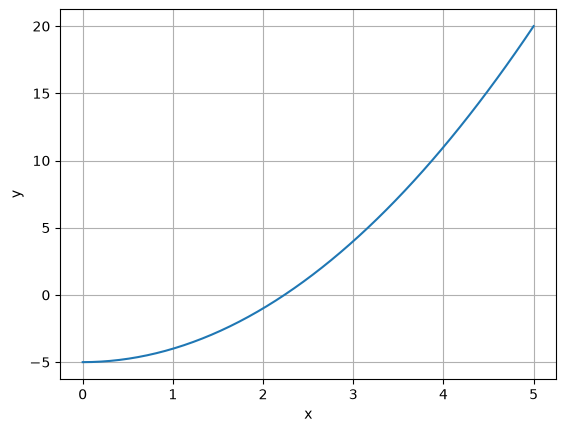

In [16]:
x = np.linspace(0, 5, 50)
y = f(x)
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

## Equilibrium temperature of solid and liquid (melting point)

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sym # used for symbolic python
from scipy.optimize import fsolve

### symbolic python (computer algebra system)

In [19]:
u = sym.Symbol('u')
v = sym.Symbol('v')
w = u + u*v
display(w)

u*v + u

In [20]:
dwdu = sym.diff(w, u)
display(dwdu)

v + 1

In [33]:
# Define symbolic temperature variable
T = sym.Symbol('T')
# Define coefficients for truncated free energy (excluding cubic and higher terms):
# G(T) = a + b*T + c*T*log(T) + d*T**2 + f_coef/T

# Solid phase parameters
a_s, b_s, c_s, d_s, f_s = 1000.0, -10.0, -25.0, -0.01, 100.0
g_s = a_s + b_s*T + c_s*T*sym.log(T) + d_s*T**2 + f_s/T

# Liquid phase parameters
a_l, b_l, c_l, d_l, f_l = 12000.0, -20.0, -30.0, -0.005, 50.0
g_l = a_l + b_l*T + c_l*T*sym.log(T) + d_l*T**2 + f_l/T
display('g_s: ', g_s)
display('g_l: ', g_l)

'g_s: '

-0.01*T**2 - 25.0*T*log(T) - 10.0*T + 1000.0 + 100.0/T

'g_l: '

-0.005*T**2 - 30.0*T*log(T) - 20.0*T + 12000.0 + 50.0/T

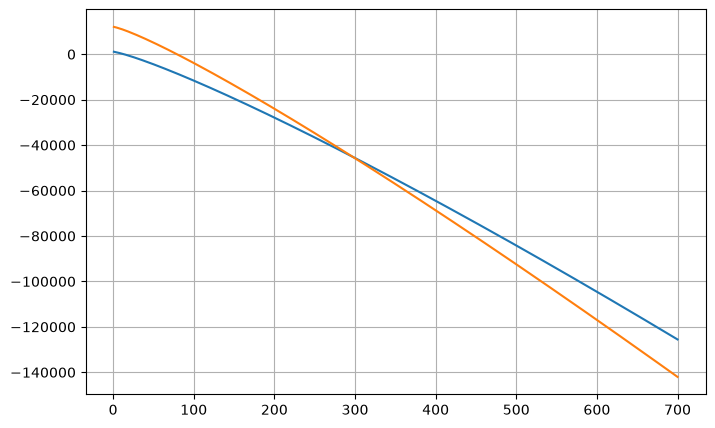

In [36]:
g_s_func = sym.lambdify(T, g_s, "numpy")
g_l_func = sym.lambdify(T, g_l, "numpy")

T_vals = np.linspace(1, 700, 200) # Temperature range

plt.figure(figsize=(8, 5))
plt.plot(T_vals, g_s_func(T_vals), label=r"Solid Phase ($G_s$)")
plt.plot(T_vals, g_l_func(T_vals), label=r"Liquid Phase ($G_l$)")
plt.grid()
plt.show()

In [25]:
# 1. Equilibrium condition Delta G(T) = G_s - G_l = 0
f_sym = g_s - g_l
display("f:", f_sym)
# 2. Compute derivative d(Delta G)/dT symbolically
df_sym = sym.diff(f_sym, T)
display("df:", df_sym)
# 3. Lambdify symbolic expressions into numerical functions
f = sym.lambdify(T, f_sym, 'numpy')
df = sym.lambdify(T, df_sym, 'numpy')

T_vals = np.linspace(1, 1400, 200)

# 4. Newton-Raphson Solver
def newton_raphson(f, df, T0, tol=1e-6, max_iter=100):
    T_curr = T0
    for i in range(max_iter):
        f_val = f(T_curr)
        df_val = df(T_curr)
        print("iteration = ", i, "f = ", f_val)
        if abs(f_val) < tol: # convergence criteria
            return T_curr, i
        
        T_curr = T_curr - f_val / df_val
        

T_initial = 1000.0 # Initial guess
T_eq, iterations = newton_raphson(f, df, T0=T_initial)

print(f"Equilibrium Melting Temperature: {T_eq:.4f} K")
print(f"Converged in {iterations} iterations.")

'f:'

-0.005*T**2 + 5.0*T*log(T) + 10.0*T - 11000.0 + 50.0/T

'df:'

-0.01*T + 5.0*log(T) + 15.0 - 50.0/T**2

iteration =  0 f =  28538.82639491068
iteration =  1 f =  -775.5441318422662
iteration =  2 f =  1.3988584563008932
iteration =  3 f =  4.065277807802081e-06
iteration =  4 f =  -1.2594647547103932e-12
Equilibrium Melting Temperature: 297.3873 K
Converged in 4 iterations.
Equilibrium Melting Temperature fsolve: 297.3873 K


In [26]:
# Using builtin fsolve
T_eq_fsolve = fsolve(f, T_initial)[0]
print(f"Equilibrium Melting Temperature fsolve: {T_eq_fsolve:.4f} K")

Equilibrium Melting Temperature fsolve: 297.3873 K
